# Prototype Verifikasi Ijazah: OCR Nomor Ijazah + Deteksi Tanda Tangan

**Pipeline**

```
Citra Ijazah → Grayscale → Image Enhancement
        ├─ Area Nomor Ijazah  → Enhancement → OCR → Nomor Ijazah
        └─ Area Tanda Tangan  → Thresholding → Morphology → Signature Detection
                              ↓
                       Hasil Verifikasi
```

**Cara pakai:** ubah `IMAGE_PATH` di sel konfigurasi, lalu jalankan semua sel (*Run All*).

## 0. Instalasi (jalankan sekali)
Butuh **Tesseract OCR** di sistem. Di Google Colab/Ubuntu: jalankan sel di bawah. Di Windows: install dari https://github.com/UB-Mannheim/tesseract/wiki lalu set `TESSERACT_CMD`.

In [2]:
# Colab / Ubuntu. Hapus tanda '#' jika perlu.
!apt-get -qq install -y tesseract-ocr
!pip -q install opencv-python-headless pytesseract matplotlib numpy

## 1. Import & Konfigurasi

In [3]:
import re
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt

# ========== GANTI NAMA FILE DI SINI ==========
IMAGE_PATH = "01_HighQuality_Enhanced.jpg"     # contoh: "ijazah_001.jpg"
# =============================================

# Windows saja (sesuaikan lokasi instalasi):
# pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Lokasi area dinyatakan RELATIF terhadap ukuran gambar: (x1, y1, x2, y2) dalam rentang 0..1
# sehingga tetap bekerja walau resolusi gambar berbeda, selama tata letak ijazah sama.
# Jika tata letak ijazah lain berbeda, cukup ubah angka-angka ini (lihat visualisasi di langkah 4).
ROI_NOMOR = (0.04, 0.90, 0.32, 0.97)           # "Nomor ijazah: ..."
ROI_TTD = {
    "Rektor":  (0.12, 0.72, 0.40, 0.83),
    "Dekan":   (0.62, 0.66, 0.88, 0.84),
}
# Tanda tangan yang WAJIB ada agar hasil akhir = PRESENT.
# (Tanda tangan pemilik ijazah hanya ditampilkan sebagai informasi tambahan.)
ROI_TTD_PEMILIK = (0.44, 0.85, 0.52, 0.92)
TTD_WAJIB = ["Rektor", "Dekan"]

# Parameter deteksi tanda tangan
MIN_INK_RATIO   = 0.008   # minimal proporsi piksel tinta dalam area
MIN_COMP_AREA   = 1200    # minimal luas komponen goresan terbesar (piksel)
MIN_COMP_WIDTH  = 0.15    # lebar komponen terbesar minimal 15% lebar area

## 2. Fungsi-fungsi Pipeline

In [4]:
def crop(img, roi):
    """Potong gambar berdasarkan ROI relatif (x1,y1,x2,y2)."""
    h, w = img.shape[:2]
    x1, y1, x2, y2 = roi
    return img[int(y1*h):int(y2*h), int(x1*w):int(x2*w)]


def to_gray(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)


def enhance_global(gray):
    """Image enhancement umum: denoise ringan + CLAHE (menaikkan kontras lokal)."""
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(blur)


# ---------------- Jalur 1: Nomor Ijazah ----------------
def enhance_number_area(roi_gray):
    """Enhancement khusus area nomor: upscale, binarisasi Otsu."""
    up = cv2.resize(roi_gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    _, binary = cv2.threshold(up, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # beri margin putih agar Tesseract lebih stabil
    return cv2.copyMakeBorder(binary, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=255)


def parse_nomor(text):
    """Ambil nomor ijazah dari teks OCR. Menerima huruf/angka/tanda '-' (mis. DN-123456789)."""
    text = text.strip().replace("\n", " ")
    m = re.search(r":\s*([A-Za-z0-9\-\./]{6,})", text)       # nomor setelah tanda ':'
    if m:
        return m.group(1).upper()
    tokens = re.findall(r"[A-Za-z0-9\-\./]{8,}", text)       # fallback: token terpanjang
    return max(tokens, key=len).upper() if tokens else None


def read_nomor_ijazah(roi_gray):
    prepared = enhance_number_area(roi_gray)
    raw = pytesseract.image_to_string(prepared, config="--oem 3 --psm 7")
    if not parse_nomor(raw):                                   # coba mode lain jika gagal
        raw = pytesseract.image_to_string(prepared, config="--oem 3 --psm 6")
    return parse_nomor(raw), raw.strip(), prepared


# ---------------- Jalur 2: Tanda Tangan ----------------
def threshold_signature(roi_gray):
    """Thresholding: ambil piksel yang LEBIH GELAP dari latar lokalnya.
    Cara ini kebal terhadap pola guilloche/watermark kuning pada ijazah."""
    blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)
    k = 51 if min(blur.shape) > 51 else (min(blur.shape) // 2) * 2 + 1
    background = cv2.medianBlur(blur, k)
    diff = cv2.subtract(background, blur)
    _, binary = cv2.threshold(diff, 60, 255, cv2.THRESH_BINARY)
    return binary


def morphology_signature(binary):
    """Morphology: closing untuk menyambung goresan tanda tangan yang putus-putus."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    return cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)


def detect_signature(morph):
    """Putuskan ada/tidaknya tanda tangan dari rasio tinta & ukuran komponen terbesar."""
    h, w = morph.shape
    ink_ratio = float(np.count_nonzero(morph)) / (h * w)
    n, _, stats, _ = cv2.connectedComponentsWithStats(morph)
    if n > 1:
        i = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        comp_area = int(stats[i, cv2.CC_STAT_AREA])
        comp_width = stats[i, cv2.CC_STAT_WIDTH] / w
    else:
        comp_area, comp_width = 0, 0.0
    present = (ink_ratio >= MIN_INK_RATIO and comp_area >= MIN_COMP_AREA
               and comp_width >= MIN_COMP_WIDTH)
    return present, {"ink_ratio": round(ink_ratio, 4), "komponen_terbesar": comp_area,
                     "lebar_relatif": round(float(comp_width), 2)}


def analyze_signature(gray_enh, roi):
    area = crop(gray_enh, roi)
    binary = threshold_signature(area)
    morph = morphology_signature(binary)
    present, info = detect_signature(morph)
    return present, info, area, binary, morph

## 3. Jalankan Pipeline

In [5]:
def verify_ijazah(path, show=True):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Gagal membaca gambar: {path}")

    # 1) Grayscale -> 2) Image Enhancement
    gray = to_gray(img)
    enhanced = enhance_global(gray)

    # 3a) Jalur nomor ijazah: crop -> enhancement -> OCR
    nomor, raw_text, num_prepared = read_nomor_ijazah(crop(enhanced, ROI_NOMOR))

    # 3b) Jalur tanda tangan: crop -> thresholding -> morphology -> deteksi
    # (threshold dilakukan pada gray asli agar tinta tidak ikut 'terhapus' oleh CLAHE)
    sig = {}
    for nama, roi in ROI_TTD.items():
        sig[nama] = analyze_signature(gray, roi)
    sig_pemilik = analyze_signature(gray, ROI_TTD_PEMILIK)

    # 4) Hasil verifikasi
    ttd_ok = all(sig[n][0] for n in TTD_WAJIB)
    hasil = {
        "nomor_ijazah": nomor,
        "tanda_tangan": "PRESENT" if ttd_ok else "ABSENT",
        "detail": {n: ("PRESENT" if sig[n][0] else "ABSENT") for n in sig},
        "pemilik": "PRESENT" if sig_pemilik[0] else "ABSENT",
    }

    if show:
        visualize(img, gray, enhanced, num_prepared, raw_text, sig, sig_pemilik)
    return hasil


def visualize(img, gray, enhanced, num_prepared, raw_text, sig, sig_pemilik):
    # Gambar utama dengan kotak area yang dianalisis
    vis = img.copy()
    h, w = vis.shape[:2]
    def box(roi, color, label):
        x1, y1, x2, y2 = roi
        p1, p2 = (int(x1*w), int(y1*h)), (int(x2*w), int(y2*h))
        cv2.rectangle(vis, p1, p2, color, 4)
        cv2.putText(vis, label, (p1[0], p1[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 1.4, color, 3)
    box(ROI_NOMOR, (0, 0, 255), "Nomor")
    for n, r in ROI_TTD.items():
        box(r, (0, 160, 0), n)
    box(ROI_TTD_PEMILIK, (255, 120, 0), "Pemilik")

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax[0].set_title("Area yang dianalisis")
    ax[1].imshow(gray, cmap="gray");                   ax[1].set_title("Grayscale")
    ax[2].imshow(enhanced, cmap="gray");               ax[2].set_title("Enhancement (CLAHE)")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

    # Detail jalur nomor
    plt.figure(figsize=(9, 2.2))
    plt.imshow(num_prepared, cmap="gray"); plt.axis("off")
    plt.title(f"Area nomor setelah enhancement | OCR mentah: {raw_text!r}")
    plt.show()

    # Detail jalur tanda tangan
    items = list(sig.items()) + [("Pemilik", sig_pemilik)]
    fig, ax = plt.subplots(len(items), 3, figsize=(13, 3.2*len(items)))
    for r, (nama, (present, info, area, binary, morph)) in enumerate(items):
        ax[r, 0].imshow(area, cmap="gray"); ax[r, 0].set_title(f"{nama}: area (gray)")
        ax[r, 1].imshow(binary, cmap="gray"); ax[r, 1].set_title("Thresholding")
        ax[r, 2].imshow(morph, cmap="gray"); ax[r, 2].set_title(f"Morphology -> {'PRESENT' if present else 'ABSENT'}")
        for a in ax[r]: a.axis("off")
    plt.tight_layout(); plt.show()

## 4. Hasil Verifikasi

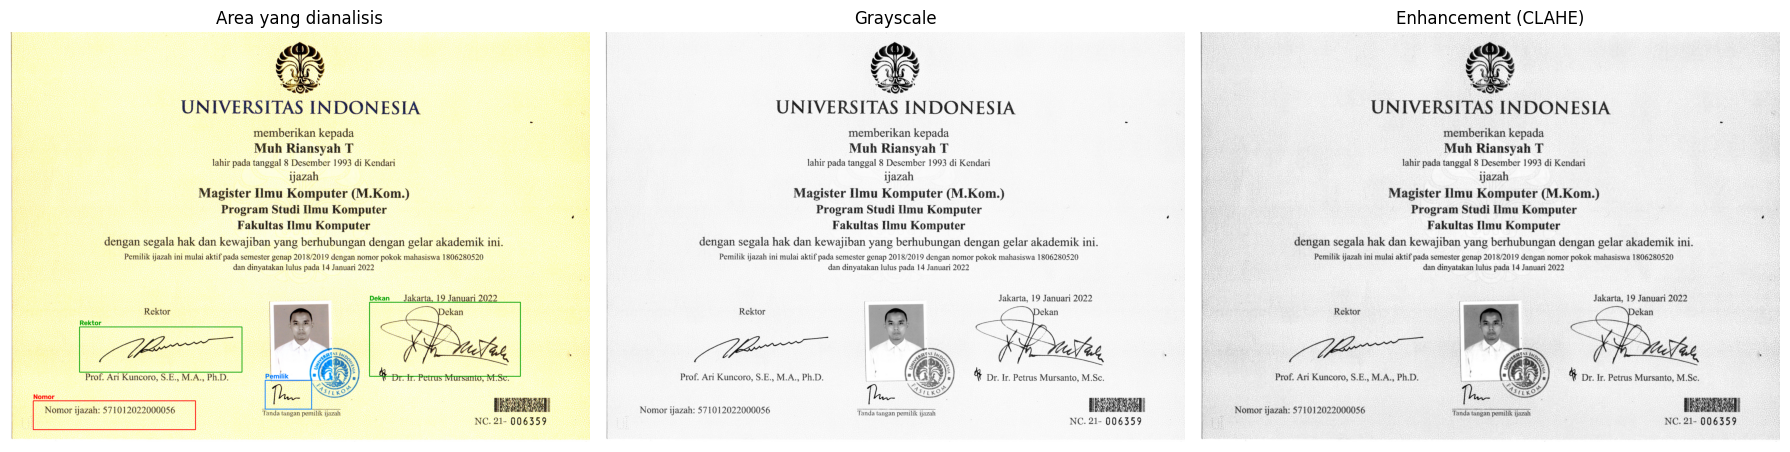

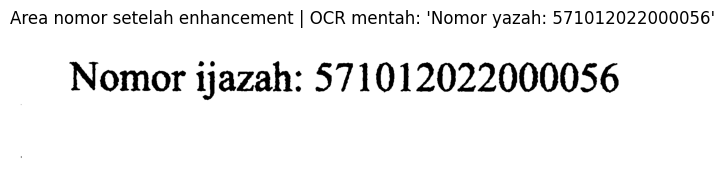

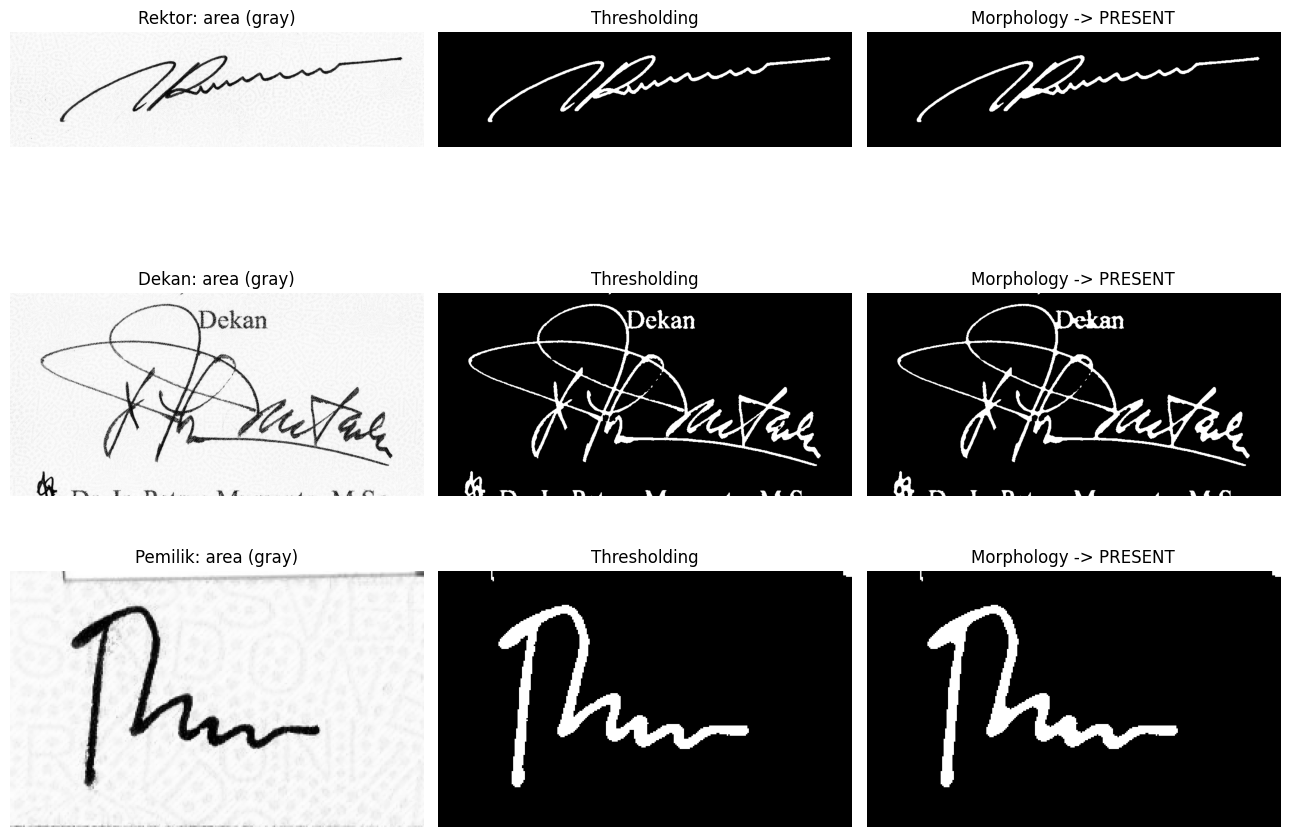

Input         : 01_HighQuality_Enhanced.jpg
Nomor Ijazah  : 571012022000056
Tanda Tangan  : PRESENT
----------------------------------------
  - Rektor  : PRESENT
  - Dekan   : PRESENT
  - Pemilik : PRESENT (informasi tambahan)


In [6]:
hasil = verify_ijazah(IMAGE_PATH)

print("=" * 40)
print("Input         :", IMAGE_PATH)
print("Nomor Ijazah  :", hasil["nomor_ijazah"])
print("Tanda Tangan  :", hasil["tanda_tangan"])
print("-" * 40)
for n, s in hasil["detail"].items():
    print(f"  - {n:<8}: {s}")
print(f"  - Pemilik : {hasil['pemilik']} (informasi tambahan)")
print("=" * 40)

## 5. (Opsional) Proses Banyak File Sekaligus

In [ ]:
# import glob
# for f in sorted(glob.glob("ijazah_*.jpg")):
#     r = verify_ijazah(f, show=False)
#     print(f"{f} | Nomor Ijazah : {r['nomor_ijazah']} | Tanda Tangan : {r['tanda_tangan']}")